In [1]:
import sympy as sp
import sympy.physics.mechanics as me 
me.init_vprinting()

A, B = sp.symbols('A B', cls=me.ReferenceFrame)
theta = me.dynamicsymbols('theta')

In [2]:
B.orient_axis(A, theta, A.y)

In [3]:
P = 2*me.outer(B.x, B.x) + 3*me.outer(A.x, B.y) + 4*me.outer(B.z, A.z)
P

In [4]:
P.to_matrix(A)

⎡        2                                       ⎤
⎢   2⋅cos (θ)      3  -2⋅sin(θ)⋅cos(θ) + 4⋅sin(θ)⎥
⎢                                                ⎥
⎢       0          0               0             ⎥
⎢                                                ⎥
⎢                             2                  ⎥
⎣-2⋅sin(θ)⋅cos(θ)  0     2⋅sin (θ) + 4⋅cos(θ)    ⎦

In [5]:
P.express(A)

In [6]:
A, B = sp.symbols('A B', cls=me.ReferenceFrame)
w1, w2, w3 = me.dynamicsymbols('omega1:4')
M1, M2, M3 = me.dynamicsymbols('M1:4')
I11, I22, I33 = sp.symbols('I_11 I_22 I_33')
t = me.dynamicsymbols._t


In [7]:
I = I11*me.outer(B.x,B.x) + I22*me.outer(B.y,B.y) + I33*me.outer(B.z,B.z)
I

In [8]:

A_w_B = w1*B.x + w2*B.y + w3*B.z
A_w_B

In [9]:
M = M1*B.x + M2*B.y + M3*B.z
M


In [10]:
H = I.dot(A_w_B)
H

In [11]:
Hdot = H.dt(B) + me.cross(A_w_B, H)
Hdot

In [12]:
sp.Eq(M.to_matrix(B),Hdot.to_matrix(B))

⎡M₁⎤   ⎡I₁₁⋅ω₁̇ - I₂₂⋅ω₂⋅ω₃ + I₃₃⋅ω₂⋅ω₃ ⎤
⎢  ⎥   ⎢                               ⎥
⎢M₂⎥ = ⎢I₁₁⋅ω₁⋅ω₃ + I₂₂⋅ω₂̇ - I₃₃⋅ω₁⋅ω₃ ⎥
⎢  ⎥   ⎢                               ⎥
⎣M₃⎦   ⎣-I₁₁⋅ω₁⋅ω₂ + I₂₂⋅ω₁⋅ω₂ + I₃₃⋅ω₃̇⎦

In [13]:
B, H = sp.symbols('B H', cls=me.ReferenceFrame)

m_h, m_b = sp.symbols('m_h m_b')

r_Ho_O = 0.4*B.x - 1.1*B.z
r_Bo_O = 0.3*B.x - 0.5*B.z

I_B_Bo = 0.5*me.outer(B.x,B.x) + 1.3*me.outer(B.y,B.y) + 0.8*me.outer(B.z,B.z) - 0.1*me.outer(B.x,B.z) - 0.1*me.outer(B.z,B.x)
I_H_Ho = 11.3*me.outer(H.x,H.x) + 11.0*me.outer(H.y,H.y) + 2.3*me.outer(H.z,H.z) - 1.7*me.outer(H.y,H.z) - 1.7*me.outer(H.z,H.y)


I_B_Bo.to_matrix(B), I_H_Ho.to_matrix(H)


⎛⎡0.5    0   -0.1⎤  ⎡11.3   0     0  ⎤⎞
⎜⎢               ⎥  ⎢                ⎥⎟
⎜⎢ 0    1.3   0  ⎥, ⎢ 0    11.0  -1.7⎥⎟
⎜⎢               ⎥  ⎢                ⎥⎟
⎝⎣-0.1   0   0.8 ⎦  ⎣ 0    -1.7  2.3 ⎦⎠

In [14]:
m_h = 84.0
m_b = 9.9

In [15]:
r_Ho_O, r_Bo_O

In [16]:
B_c_H = sp.Matrix([[0, -1, 0],
                  [-1, 0, 0],
                  [0, 0, -1]])
B_c_H

⎡0   -1  0 ⎤
⎢          ⎥
⎢-1  0   0 ⎥
⎢          ⎥
⎣0   0   -1⎦

In [17]:
B.orient_explicit(H, B_c_H.transpose())

In [18]:
r_Fo_O = (m_b*r_Bo_O + m_h*r_Ho_O)/(m_b+ m_h)
r_Fo_O

In [19]:
r_Fo_Ho = r_Fo_O - r_Ho_O
r_Fo_Bo = r_Fo_O - r_Bo_O

r_Fo_Ho,    r_Fo_Bo

In [20]:
U = me.outer(H.x,H.x) + me.outer(H.y,H.y) + me.outer(H.z,H.z)
U

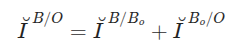
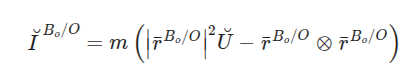

In [21]:
I_Bo_Fo = m_b*(r_Fo_Bo.dot(r_Fo_Bo)*U - me.outer(r_Fo_Bo,r_Fo_Bo))
I_Bo_Fo

In [22]:
I_Ho_Fo = m_h*(r_Fo_Ho.dot(r_Fo_Ho)*U - me.outer(r_Fo_Ho,r_Fo_Ho))
I_Ho_Fo

In [23]:
I_B_Fo = I_Bo_Fo + I_B_Bo
I_H_Fo = I_Ho_Fo + I_H_Ho

I_F_Fo = I_B_Fo + I_H_Fo
I_F_Fo.to_matrix(B)

⎡14.6882428115016          0          -1.26862619808307⎤
⎢                                                      ⎥
⎢        0          15.8768051118211          0        ⎥
⎢                                                      ⎥
⎣-1.26862619808307         0          3.18856230031949 ⎦